# TP : Reconnaissance de patterns avec les réseaux de neurones MLP

**Master 2 Cybersécurité - Intelligence Artificielle**

Ce TP a pour objectif de vous familiariser avec les réseaux de neurones artificiels, en particulier les perceptrons multicouches (MLP), à travers une tâche de reconnaissance de patterns.

## Objectifs pédagogiques
- Comprendre le fonctionnement d un réseau de neurones MLP
- Implémenter un modèle de classification supervisée
- Évaluer les performances du modèle
- Interpréter les résultats obtenus

## Partie 1 : Préparation des données
1. Importez les bibliothèques nécessaires
2. Chargez le jeu de données `digits` de sklearn
3. Affichez quelques exemples d images
4. Divisez les données en ensembles d entraînement et de test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

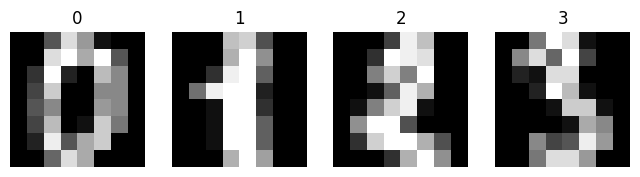

In [ ]:
digits = datasets.load_digits()

fig, axes = plt.subplots(1, 4, figsize=(8, 3))
for i in range(4):
    axes[i].imshow(digits.images[i], cmap="gray")
    axes[i].set_title(digits.target[i])
    axes[i].axis("off")
plt.show()

In [3]:
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train : {len(X_train)} samples")
print(f"Test  : {len(X_test)} samples")

Train : 1257 samples
Test  : 540 samples


## Partie 2 : Construction du modèle MLP
1. Créez un modèle MLP avec `MLPClassifier` de sklearn
2. Choisissez une architecture adaptée (nombre de couches cachées, neurones, etc.)
3. Entraînez le modèle sur les données d entraînement

In [4]:
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
mlp.fit(X_train, y_train)

print(f"Score train : {mlp.score(X_train, y_train):.4f}")
print(f"Score test  : {mlp.score(X_test, y_test):.4f}")

Score train : 1.0000
Score test  : 0.9796


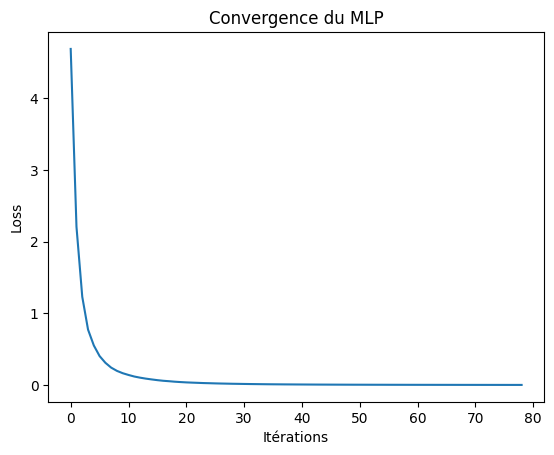

In [ ]:
plt.plot(mlp.loss_curve_)
plt.xlabel("Itérations")
plt.ylabel("Loss")
plt.title("Convergence du MLP")
plt.show()

## Partie 3 : Évaluation du modèle
1. Prédisez les classes sur l ensemble de test
2. Affichez la matrice de confusion
3. Calculez la précision, le rappel et le score F1
4. Interprétez les résultats

In [8]:
y_pred = mlp.predict(X_test)

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}")

Accuracy  : 0.9796
Precision : 0.9797
Recall    : 0.9796
F1 Score  : 0.9796


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       1.00      1.00      1.00        50
           2       0.96      1.00      0.98        47
           3       0.96      0.96      0.96        54
           4       0.98      1.00      0.99        60
           5       0.97      0.95      0.96        66
           6       0.98      0.98      0.98        53
           7       0.98      0.98      0.98        55
           8       1.00      0.98      0.99        43
           9       0.98      0.97      0.97        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



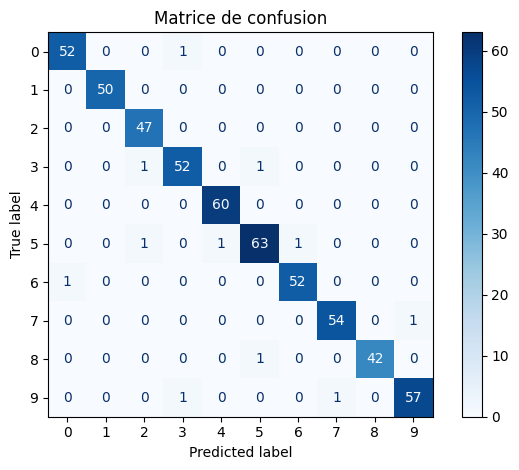

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

## Partie 4 : Visualisation des erreurs
1. Identifiez les exemples mal classés
2. Affichez quelques images avec leur prédiction erronée

11 erreurs sur 540 images


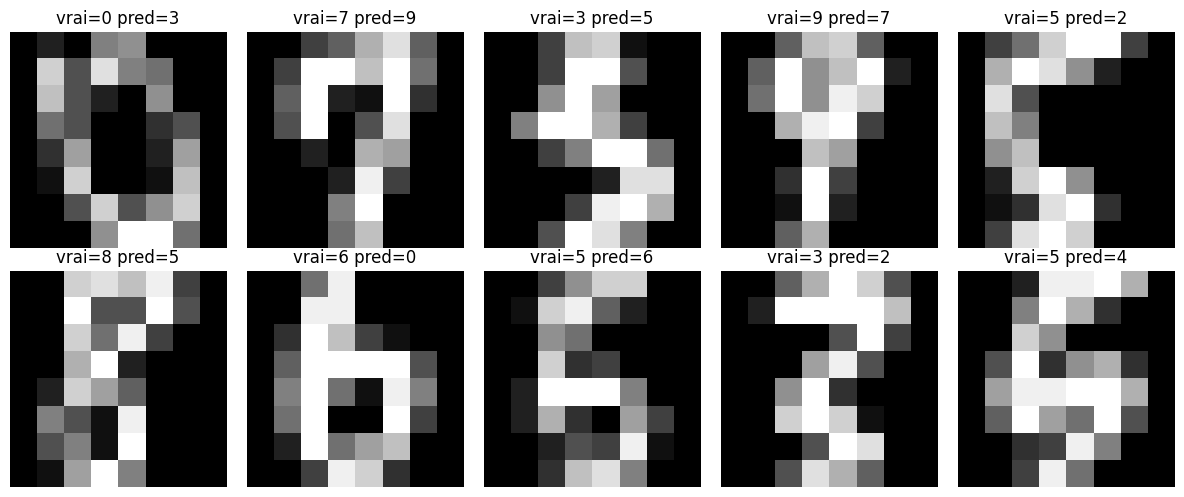

In [11]:
erreurs = np.where(y_pred != y_test)[0]
print(f"{len(erreurs)} erreurs sur {len(y_test)} images")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, idx in enumerate(erreurs[:10]):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test[idx].reshape(8, 8), cmap="gray")
    ax.set_title(f"vrai={y_test[idx]} pred={y_pred[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Partie 5 : Discussion
1. Quels sont les avantages et limites des MLP pour la reconnaissance de patterns ?
2. Comment améliorer les performances du modèle ?
3. Quelle est la pertinence de cette approche en cybersécurité ?